In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# Define symbols and function
x, y = sp.symbols('x y')
f = x**2 + y**2
f

x**2 + y**2

In [3]:
# Compute partial derivatives
df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)

In [4]:
df_dx

2*x

In [5]:
df_dy

2*y

In [6]:
# Grid
x_vals = np.linspace(-3, 3, 7)
y_vals = np.linspace(-3, 3, 7)
X, Y = np.meshgrid(x_vals, y_vals)

In [7]:
X

array([[-3., -2., -1.,  0.,  1.,  2.,  3.],
       [-3., -2., -1.,  0.,  1.,  2.,  3.],
       [-3., -2., -1.,  0.,  1.,  2.,  3.],
       [-3., -2., -1.,  0.,  1.,  2.,  3.],
       [-3., -2., -1.,  0.,  1.,  2.,  3.],
       [-3., -2., -1.,  0.,  1.,  2.,  3.],
       [-3., -2., -1.,  0.,  1.,  2.,  3.]])

In [8]:
Y

array([[-3., -3., -3., -3., -3., -3., -3.],
       [-2., -2., -2., -2., -2., -2., -2.],
       [-1., -1., -1., -1., -1., -1., -1.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 2.,  2.,  2.,  2.,  2.,  2.,  2.],
       [ 3.,  3.,  3.,  3.,  3.,  3.,  3.]])

In [9]:
# Convert to numerical functions
f_func = sp.lambdify((x, y), f, 'numpy')

df_dx_func = sp.lambdify((x, y), df_dx, 'numpy')
df_dy_func = sp.lambdify((x, y), df_dy, 'numpy')

Z = f_func(X, Y)
Z # outcome or the third dimension coming out of X and Y function

array([[18., 13., 10.,  9., 10., 13., 18.],
       [13.,  8.,  5.,  4.,  5.,  8., 13.],
       [10.,  5.,  2.,  1.,  2.,  5., 10.],
       [ 9.,  4.,  1.,  0.,  1.,  4.,  9.],
       [10.,  5.,  2.,  1.,  2.,  5., 10.],
       [13.,  8.,  5.,  4.,  5.,  8., 13.],
       [18., 13., 10.,  9., 10., 13., 18.]])

In [10]:
DX = df_dx_func(X, Y)
DY = df_dy_func(X, Y)

In [11]:
DX

array([[-6., -4., -2.,  0.,  2.,  4.,  6.],
       [-6., -4., -2.,  0.,  2.,  4.,  6.],
       [-6., -4., -2.,  0.,  2.,  4.,  6.],
       [-6., -4., -2.,  0.,  2.,  4.,  6.],
       [-6., -4., -2.,  0.,  2.,  4.,  6.],
       [-6., -4., -2.,  0.,  2.,  4.,  6.],
       [-6., -4., -2.,  0.,  2.,  4.,  6.]])

In [12]:
DY

array([[-6., -6., -6., -6., -6., -6., -6.],
       [-4., -4., -4., -4., -4., -4., -4.],
       [-2., -2., -2., -2., -2., -2., -2.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 2.,  2.,  2.,  2.,  2.,  2.,  2.],
       [ 4.,  4.,  4.,  4.,  4.,  4.,  4.],
       [ 6.,  6.,  6.,  6.,  6.,  6.,  6.]])

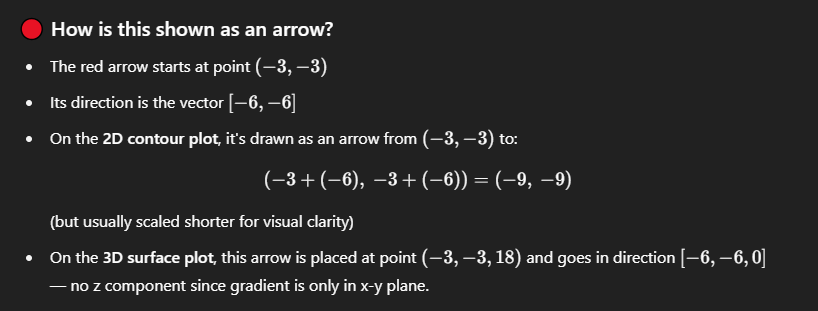

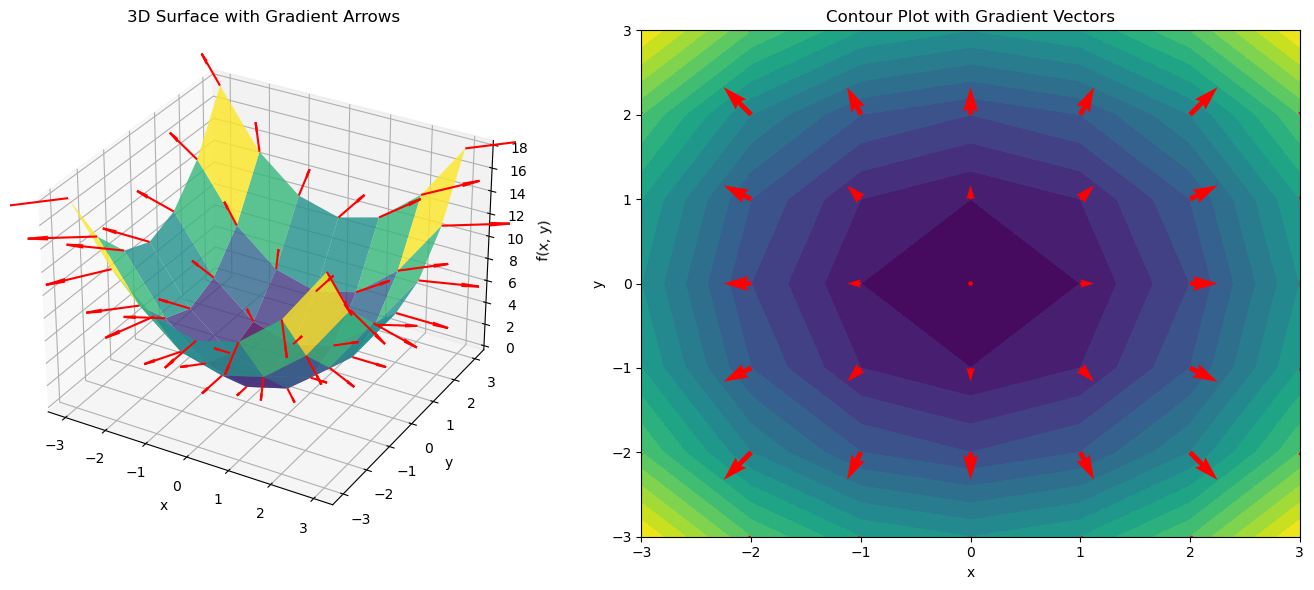

In [13]:
# Plot
fig = plt.figure(figsize=(14, 6))

# 3D Surface + Gradient
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.quiver(X, Y, Z, DX, DY, np.zeros_like(Z), color='red', length=0.2)
ax1.set_title("3D Surface with Gradient Arrows")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')

# Contour + Gradient
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X, Y, Z, cmap='viridis', levels=20)
ax2.quiver(X, Y, DX, DY, color='red')
ax2.set_title("Contour Plot with Gradient Vectors")
ax2.set_xlabel('x')
ax2.set_ylabel('y')

plt.tight_layout()
plt.show()

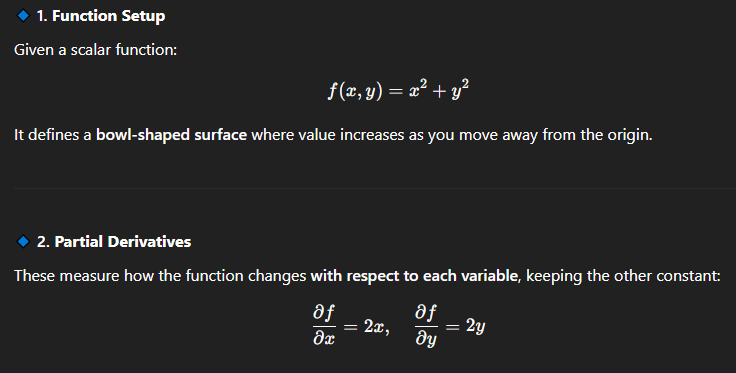
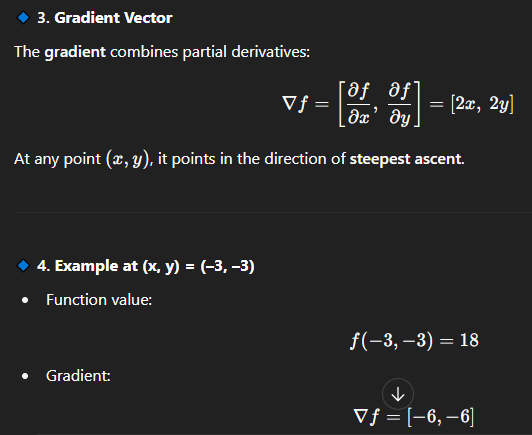
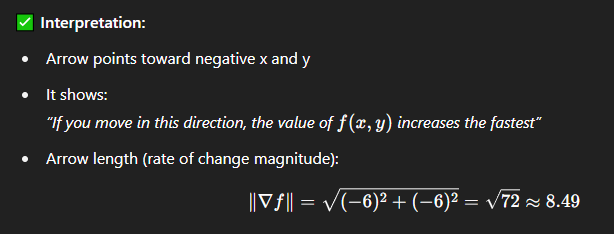
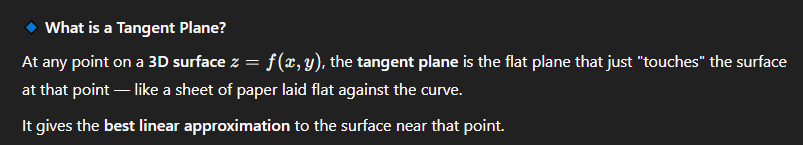

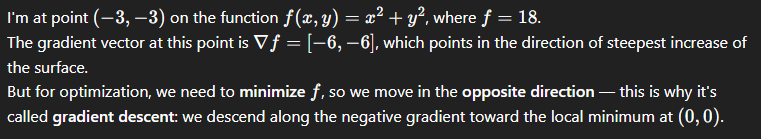